# IBM HR Analysis

## Observations
- Dataset has 34 features plus 1 UID (Empmployee number)
- Categorical Data (7 Features) is already encoded
  - Attrition (True, False)
  - BusinessTravel (Travel_Rarely, Travel_Frequently,  Non-Travel)
  - Department (Research & Development, Sales,  Human Resources)
  - Education Field (Life Sciences, Medical, Marketing,  Technical Degree, Other)
  - Gender (Male, Female)
  - 
  - Already Encoded
    - Education (1 ='Below College', 2 = 'College', 3 = 'Bachelor', 4 = 'Master', 5 'Doctor')
    - EnvironmentSatisfaction (1 = 'Low', 2 = 'Medium', 3 = 'High', 4 = 'Very High')
    - JobInvolvement (1 = 'Low', 2 = 'Medium', 3 = 'High', 4 = 'Very High')
    - JobSatisfaction (1 = 'Low', 2 = 'Medium', 3 = 'High', 4 = 'Very High')
    - PerformanceRating (1 = 'Low', 2 = 'Good', 3 = 'Excellent', 4 = 'Outstanding')
    - RelationshipSatisfaction (1 = 'Low', 2 = 'Medium', 3 = 'High', 4 = 'Very High')
    - WorkLifeBalance (1 = 'Bad', 2 = 'Good', 3 = 'Better', 4 = 'Best')

## Objectives & Possible Questions

1. Which factors (e.g., Age, MonthlyIncome, JobRole, WorkLifeBalance, OverTime) are most associated with attrition?
2. Do performance ratings correlate with attrition, and does that relationship vary by job role or tenure?
3. How does compensation (salary, stock options, percent salary hike) relate to voluntary attrition?
4. Are there observable churn patterns by department, job level, or job role?
5. Does overtime or business travel frequency increase attrition risk?
6. How does training time or number of training courses completed affect retention and performance?
7. Are there seasonal or hiring-cohort effects in attrition (e.g., hires in certain years more likely to leave)?
8. What employee segments (clusters) exist based on demographics, performance, and engagement metrics?
9. Does manager effectiveness (e.g., ManagerID patterns or team-level attrition rates) predict individual attrition?
10. How do promotion history and time-in-role affect both performance and attrition risk?
11. What is the survival curve (time-to-attrition) for different employee groups?
12. Can dimensionality reduction (PCA/UMAP) reveal structure or outliers in employee profiles?

## Import Python packages


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from ydata_profiling import ProfileReport
import numpy as np
import scipy.stats as ss
import os

## Import data

In [30]:
ibm_df = pd.read_csv("data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

ibm_df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [31]:
print(list(ibm_df.columns))

print(ibm_df.dtypes)

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      in

In [32]:
ibm_df.info()
print(ibm_df.isna().sum())           # missing counts per column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## First Look

I am using ydata profiling to take a quick look at the data set

In [ ]:
profile = ProfileReport(ibm_df, title="HR Attrittion Profile", explorative=True)

# Save profile report 
# profile.to_file("reports/hr_attrition.html", silent=False)

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 93.51it/s]


### Insights surfaced with ydata
1. All of the workers are over 18 ("Over18"), all employees are 1 employee ("EmployeeCount")


### A little bit of descriptive statistics



In [34]:
num = ibm_df.select_dtypes(include=["number"])
print(num.describe().T)

                           count          mean          std     min      25%  \
Age                       1470.0     36.923810     9.135373    18.0    30.00   
DailyRate                 1470.0    802.485714   403.509100   102.0   465.00   
DistanceFromHome          1470.0      9.192517     8.106864     1.0     2.00   
Education                 1470.0      2.912925     1.024165     1.0     2.00   
EmployeeCount             1470.0      1.000000     0.000000     1.0     1.00   
EmployeeNumber            1470.0   1024.865306   602.024335     1.0   491.25   
EnvironmentSatisfaction   1470.0      2.721769     1.093082     1.0     2.00   
HourlyRate                1470.0     65.891156    20.329428    30.0    48.00   
JobInvolvement            1470.0      2.729932     0.711561     1.0     2.00   
JobLevel                  1470.0      2.063946     1.106940     1.0     1.00   
JobSatisfaction           1470.0      2.728571     1.102846     1.0     2.00   
MonthlyIncome             1470.0   6502.

In [35]:
cat_cols = ibm_df.select_dtypes(include=["object", "category"]).columns
for c in cat_cols:
    print("\n", c)
    print(ibm_df[c].value_counts(dropna=False))


 Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64

 BusinessTravel
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

 Department
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

 EducationField
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

 Gender
Gender
Male      882
Female    588
Name: count, dtype: int64

 JobRole
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

 MaritalStatus
MaritalStatus
Married  


## Answering Questions



### 1. Which factors (e.g., Age, MonthlyIncome, JobRole, WorkLifeBalance, OverTime) are most associated with attrition?

In [ ]:


# ensure Attrition binary for numeric tests
ibm_df["Attrition_bin"] = ibm_df["Attrition"].map({"Yes": 1, "No": 0})

numeric_cols = ibm_df.select_dtypes(include=["number"]).columns.drop("Attrition_bin")
rows = []
for c in numeric_cols:
    r, p = ss.pointbiserialr(ibm_df["Attrition_bin"], ibm_df[c])
    rows.append((c, r, p))
pd.DataFrame(rows, columns=["feature", "r_pb", "p_value"]).sort_values(
    "r_pb", key=lambda s: s.abs(), ascending=False
)

/Users/bastianwenzel/CodingSpace/git-repos/ibm-hr-data-challenge/.venv/lib/python3.9/site-packages/scipy/stats/_stats_py.py:5535: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


,feature,r_pb,p_value
19,TotalWorkingYears,-0.171063,4.061878e-11
9,JobLevel,-0.169105,6.795385e-11
23,YearsInCurrentRole,-0.160545,6.003186e-10
11,MonthlyIncome,-0.159840,7.147364e-10
0,Age,-0.159205,8.356308e-10
25,YearsWithCurrManager,-0.156199,1.736987e-09
18,StockOptionLevel,-0.137145,1.301015e-07
22,YearsAtCompany,-0.134392,2.318872e-07
8,JobInvolvement,-0.130016,5.677065e-07
10,JobSatisfaction,-0.103481,7.043067e-05


In [ ]:


def cramers_v(x, y):
    conf = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(conf, correction=False)[0]
    n = conf.sum().sum()
    phi2 = chi2 / n
    r, k = conf.shape
    # bias correction
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cat_cols = [c for c in cat_cols if c != "Attrition"]
rows = [(c, cramers_v(ibm_df[c], ibm_df["Attrition"])) for c in cat_cols]
pd.DataFrame(rows, columns=["feature", "cramers_v"]).sort_values(
    "cramers_v", ascending=False
)

/var/folders/b1/mf7xr9wx19g7mcz367bctgyr0000gn/T/ipykernel_71963/4027326311.py:14: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))


,feature,cramers_v
7,OverTime,0.244814
4,JobRole,0.230701
5,MaritalStatus,0.173386
0,BusinessTravel,0.122880
2,EducationField,0.086617
1,Department,0.077375
3,Gender,0.013671
6,Over18,NaN


In [38]:
dept = ibm_df.groupby("Department").agg(
    total=("EmployeeNumber", "count"),
    leavers=("Attrition_bin", "sum")
)
dept["attrition_rate"] = dept["leavers"] / dept["total"]
print(dept.sort_values("attrition_rate", ascending=False))

                        total  leavers  attrition_rate
Department                                            
Sales                     446       92        0.206278
Human Resources            63       12        0.190476
Research & Development    961      133        0.138398


In [39]:
pivot = ibm_df.pivot_table(
    index="JobRole", columns="JobLevel", values="MonthlyIncome", aggfunc="median"
)
print(pivot)

JobLevel                        1       2        3        4        5
JobRole                                                             
Healthcare Representative     NaN  5738.0   9854.0  13503.0      NaN
Human Resources            2696.0  5985.0   9853.0      NaN      NaN
Laboratory Technician      2691.5  4445.5   5381.0      NaN      NaN
Manager                       NaN     NaN  11910.0  16823.0  19197.0
Manufacturing Director        NaN  5280.0   9526.0  13324.5      NaN
Research Director             NaN     NaN  13198.5  16612.5  19287.0
Research Scientist         2694.0  4869.0   9724.0      NaN      NaN
Sales Executive               NaN  5454.0   9208.0  13272.5      NaN
Sales Representative       2553.0  3540.0      NaN      NaN      NaN


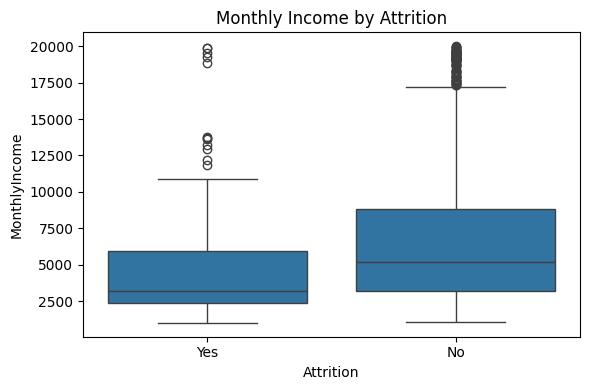

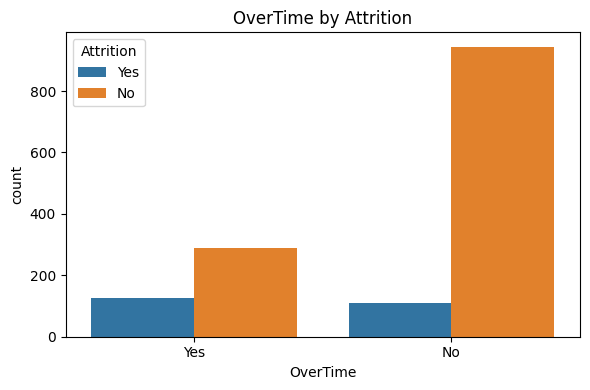

In [ ]:
os.makedirs("reports", exist_ok=True)

# 1. Boxplot (Attrition vs MonthlyIncome)
plt.figure(figsize=(6, 4))
sns.boxplot(x="Attrition", y="MonthlyIncome", data=ibm_df)
plt.title("Monthly Income by Attrition")
plt.tight_layout()
plt.savefig("reports/boxplot_attrition_income.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. Countplot (OverTime vs Attrition)
plt.figure(figsize=(6, 4))
sns.countplot(x="OverTime", hue="Attrition", data=ibm_df)
plt.title("OverTime by Attrition")
plt.tight_layout()
plt.savefig("reports/countplot_overtime_attrition.png", dpi=300, bbox_inches="tight")
plt.show()